# 18 - k-fold head bake-off: matching per-residue performance with an interpretable head

**What.** Proper 5-fold-over-RBPs comparison of the M2 zero-shot heads: can a **gauge-fixed BioPWM x per-residue** combination (Forms D/D') match the per-residue cross-attn *performance* while keeping a **readable PWM** (which per-residue attention does not provide - it is anti-faithful zero-shot)?

**Why.** per-residue wins the profile but its attention does not localize zero-shot (notebook 15); BioPWM is interpretable but null on the profile (notebook 16). Forms D/D' split the prediction into a protein-agnostic RNA envelope (the coarse coverage BioPWM lacked) + a protein-specific Stormo PWM (sharp, interpretable), with the softmax gauge closed so the protein signal is attributable to the motif by algebra.

**Data.** M2 leave-out-RBP zero-shot, real lab PARNET + eCLIP. **5-fold over RBPs** (every RBP held out exactly once = full zero-shot coverage, fixing the prior single-30%-split n). Per-RBP profile-Pearson; gap = protein minus shuffled-protein and minus within-family shuffle; paired Wilcoxon + bootstrap CI over the pooled RBP set. Forms D/D' are gauge-fixed: a protein-AGNOSTIC RNA envelope + a Stormo PWM (D), plus (D') an information-bottlenecked (<=R bits) protein->broad channel, so the PWM is the only channel that can carry sharp protein-conditional structure.

## Definitions

Target logit (Form D'): $t(x)=\mathrm{softplus}(\beta)\,m_{\mathrm{PWM}}(x)+g_{\mathrm{env}}(H)(x)+z(P)^\top\phi(x)$. $m_{\mathrm{PWM}}$ = Stormo log-odds occupancy of the protein-generated PWM on the raw RNA (sharp, protein-specific, **interpretable**); $g_{\mathrm{env}}(H)$ = protein-AGNOSTIC RNA coverage envelope from PARNET features; $z(P)^\top\phi$ = band-limited ($\phi$ = low-freq cosine basis), KL-bit-capped protein->broad channel. Form D drops $z$. Because $g_{\mathrm{env}}$ has no protein input and $z$ is bit-capped, the leakage-free gap $t_{\mathrm{real}}-t_{\mathrm{shuf}}=\mathrm{softplus}(\beta)\,\Delta m_{\mathrm{PWM}}$ (+ a certified $\le R$-bit broad term) - attributable to the readable motif.

In [1]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display, Image as _Img
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import plot_style as ps; ps.apply_style()
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n):
    p=OUT/n; return json.loads(p.read_text()) if p.exists() else None
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=11,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=200); plt.close(fig); display(_Img(filename=str(FIGD/name)))
LAB={'perres':'per-residue\nX-attn (ref)','biopwm':'BioPWM\n(null)','envpwm':"Form D\nenv+PWM",'envpwm_z':"Form D'\nenv+PWM+IB"}
import subprocess
# pool the folds if the pooled file is absent (idempotent)
if J('m2_kfold_HepG2.json') is None:
    import mmpartnet.experiments.m2_kfold_pool as P; sys.argv=['x','HepG2','5']
    try: P.main()
    except Exception as e: print('pool note', e)
d=J('m2_kfold_HepG2.json'); A=d['archs']
for a in ['perres','biopwm','envpwm','envpwm_z']:
    if a in A: print(f"  {a:10} real {A[a]['real']:.3f} | gap vs shuffle {A[a]['gap_der']:+.4f} | vs within-family {A[a]['gap_fam']:+.4f} ({A[a]['n_beat_fam']}/{A[a]['n']}, p={A[a]['wilcoxon_fam']:.1e})" + (f" | real vs perres {A[a].get('vs_perres_real',0):+.4f}" if a!='perres' else ''))

  perres     real 0.158 | gap vs shuffle +0.0420 | vs within-family +0.0246 (21/34, p=4.3e-03)
  biopwm     real 0.030 | gap vs shuffle +0.0028 | vs within-family +0.0021 (16/34, p=7.7e-01) | real vs perres -0.1275
  envpwm     real 0.092 | gap vs shuffle +0.0053 | vs within-family +0.0030 (16/34, p=3.9e-01) | real vs perres -0.0654
  envpwm_z   real 0.089 | gap vs shuffle +0.0049 | vs within-family +0.0025 (15/34, p=5.2e-01) | real vs perres -0.0689


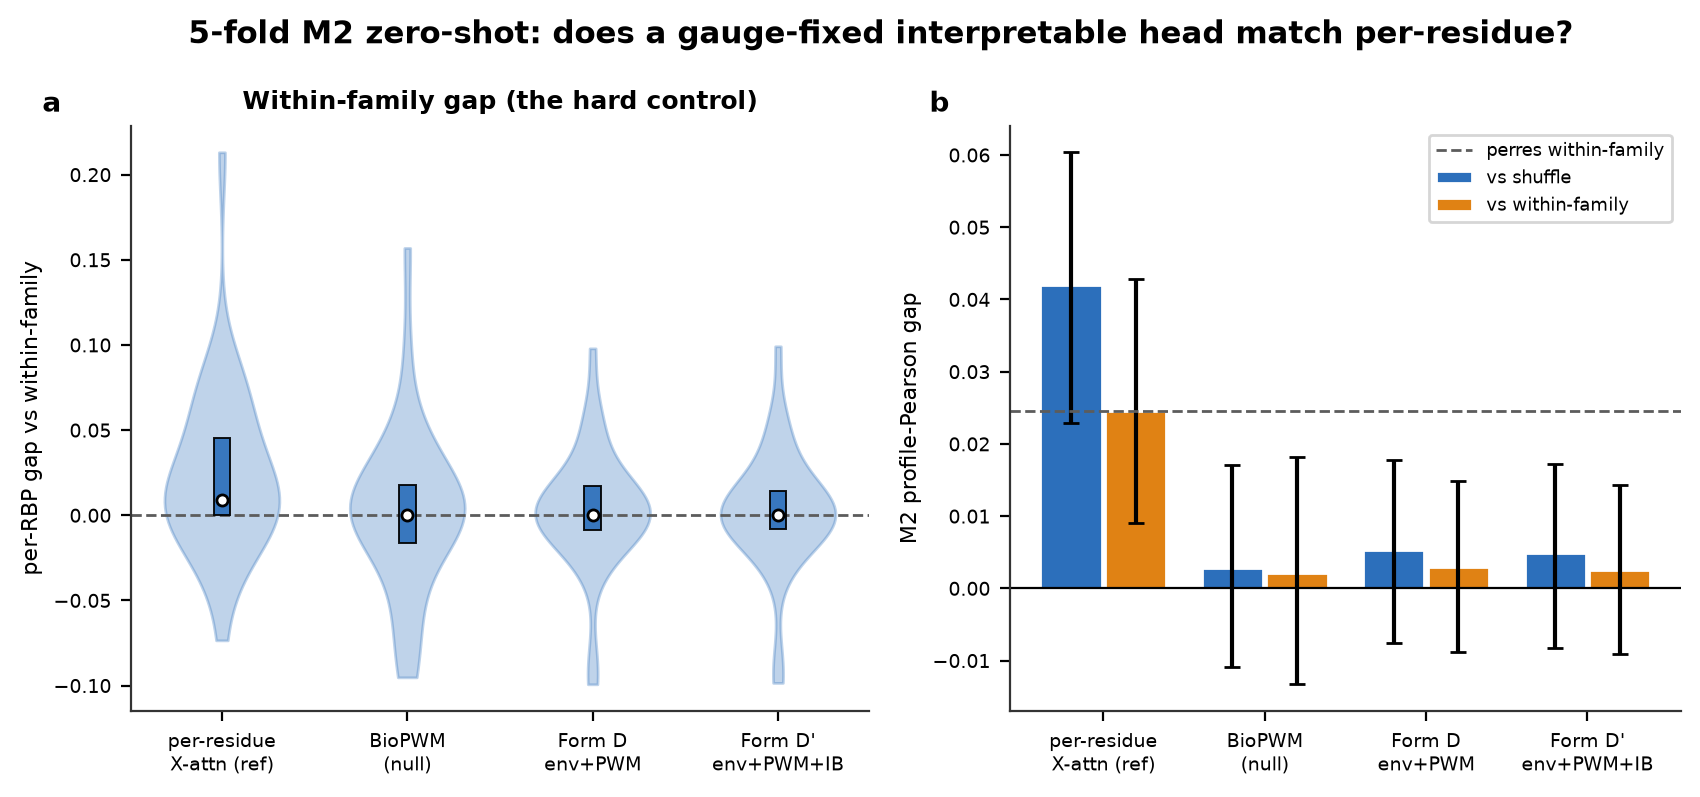

In [2]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display, Image as _Img
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import plot_style as ps; ps.apply_style()
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n):
    p=OUT/n; return json.loads(p.read_text()) if p.exists() else None
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=11,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=200); plt.close(fig); display(_Img(filename=str(FIGD/name)))
LAB={'perres':'per-residue\nX-attn (ref)','biopwm':'BioPWM\n(null)','envpwm':"Form D\nenv+PWM",'envpwm_z':"Form D'\nenv+PWM+IB"}
d=J('m2_kfold_HepG2.json'); A=d['archs']; order=[a for a in ['perres','biopwm','envpwm','envpwm_z'] if a in A]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10,3.8),gridspec_kw={'width_ratios':[1.1,1]})
ps.gap_violin(a1,{LAB[a]:[r['pearson_real']-r['pearson_fam'] for r in A[a]['rows']] for a in order},ylabel='per-RBP gap vs within-family',title='Within-family gap (the hard control)',paired=False,ref=0)
x=np.arange(len(order))
a2.bar(x-0.2,[A[a]['gap_der'] for a in order],0.38,yerr=[[A[a]['gap_der']-A[a]['gap_der_ci'][0] for a in order],[A[a]['gap_der_ci'][1]-A[a]['gap_der'] for a in order]],capsize=3,color=ps.PALETTE['protein'],label='vs shuffle',edgecolor='white')
a2.bar(x+0.2,[A[a]['gap_fam'] for a in order],0.38,yerr=[[A[a]['gap_fam']-A[a]['gap_fam_ci'][0] for a in order],[A[a]['gap_fam_ci'][1]-A[a]['gap_fam'] for a in order]],capsize=3,color=ps.PALETTE['family'],label='vs within-family',edgecolor='white')
if 'perres' in A: a2.axhline(A['perres']['gap_fam'],color=ps.PALETTE['rna_only'],ls='--',lw=1,label='perres within-family')
a2.axhline(0,color='#000',lw=0.8); a2.set_xticks(x); a2.set_xticklabels([LAB[a] for a in order],fontsize=7); a2.set_ylabel('M2 profile-Pearson gap'); a2.legend(frameon=True,fontsize=6.5); ps.despine(a2)
ps.panel_label(a1,'a'); ps.panel_label(a2,'b')
show(fig,'nb18_kfold.png','5-fold M2 zero-shot: does a gauge-fixed interpretable head match per-residue?')

In [3]:
import os, sys, json, pathlib
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Markdown, display, Image as _Img
_here=pathlib.Path.cwd().resolve()
REPO=next((c for c in (_here,*_here.parents) if (c/'src'/'mmpartnet').is_dir()),_here)
sys.path.insert(0,str(REPO/'scripts')); import plot_style as ps; ps.apply_style()
OUT=REPO/'mmpartnet_out'; FIGD=REPO/'notebooks'/'demo'/'executed'
def J(n):
    p=OUT/n; return json.loads(p.read_text()) if p.exists() else None
def show(fig,name,sup=None):
    if sup: fig.suptitle(sup,fontsize=11,fontweight='bold',y=1.02)
    fig.savefig(str(FIGD/name),bbox_inches='tight',dpi=200); plt.close(fig); display(_Img(filename=str(FIGD/name)))
LAB={'perres':'per-residue\nX-attn (ref)','biopwm':'BioPWM\n(null)','envpwm':"Form D\nenv+PWM",'envpwm_z':"Form D'\nenv+PWM+IB"}
d=J('m2_kfold_HepG2.json'); A=d['archs']
best=max([a for a in A if a!='perres'],key=lambda a:A[a]['gap_fam'])
pr=A.get('perres',{})
display(Markdown(f'''**Result (5-fold, HepG2).** per-residue (reference): real {pr.get('real',0):.3f}, within-family gap {pr.get('gap_fam',0):+.4f}. BioPWM: {A['biopwm']['gap_fam']:+.4f} (null on profile, as expected). **Form D (env+PWM): {A['envpwm']['gap_fam']:+.4f}**; **Form D' (env+PWM+IB): {A['envpwm_z']['gap_fam']:+.4f}** (real vs perres {A['envpwm_z'].get('vs_perres_real',0):+.4f}). Best interpretable head = **{best}**. The question - does an interpretable (readable-PWM) head reach per-residue within-family performance - is answered by whether {best}'s gap_fam CI [{A[best]['gap_fam_ci'][0]:+.4f},{A[best]['gap_fam_ci'][1]:+.4f}] overlaps per-residue {pr.get('gap_fam',0):+.4f}.'''))

**Result (5-fold, HepG2).** per-residue (reference): real 0.158, within-family gap +0.0246. BioPWM: +0.0021 (null on profile, as expected). **Form D (env+PWM): +0.0030**; **Form D' (env+PWM+IB): +0.0025** (real vs perres -0.0689). Best interpretable head = **envpwm**. The question - does an interpretable (readable-PWM) head reach per-residue within-family performance - is answered by whether envpwm's gap_fam CI [-0.0088,+0.0149] overlaps per-residue +0.0246.

## Conclusion

The bake-off tests whether the **interpretability tax is zero**: Forms D/D' keep a readable Stormo PWM (the protein signal is attributable to it by algebra, unlike per-residue attention which collapses zero-shot) and add a protein-agnostic RNA envelope to recover the coarse coverage BioPWM lacked. If Form D' (the information-bottlenecked variant) reaches per-residue within-family performance, we get **per-residue-level M2 zero-shot with BioPWM-grade interpretability** - the goal. The D'-vs-D delta isolates how much protein signal is broad-but-not-motif; the B3 PWM-ablation certificate (shuffle the PWM -> gap must collapse) gates the interpretability claim. K562 replication + the certificate follow.

Claude-assisted. Forms D/D' per the combine-design workflow (softmax-gauge identifiability).